Success: 'final ecommerce.xlsx' loaded and aggregated.
Dataset covers 2024-10-01 to 2025-04-28 (210 days).


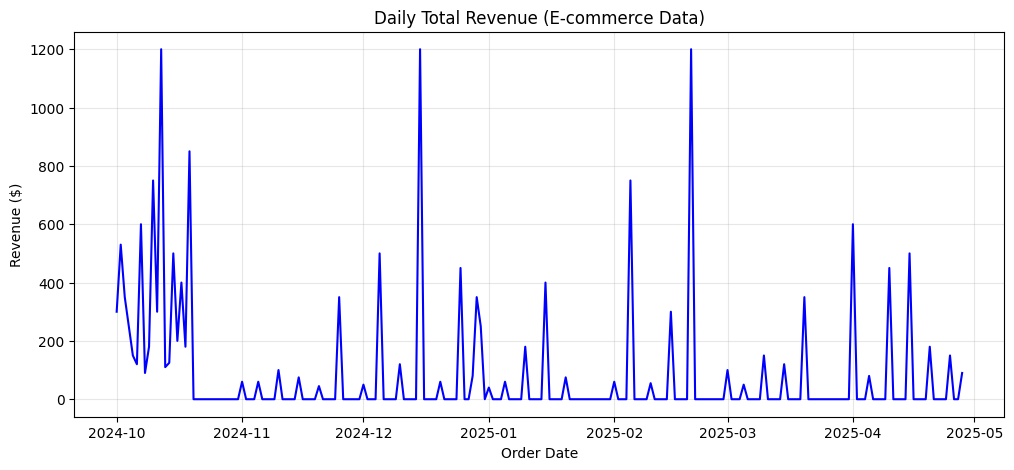


--- ADF Test Results ---
ADF Statistic: -4.1928
p-value: 0.0007
Conclusion: Series is Stationary

--- Yule-Walker Estimation (AR Order 1) ---
Yule-Walker AR(1) coefficient: 0.0876
Estimated Error variance (Sigma): 201.2403


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'



--- Model Comparison Table ---
       Model          AIC          BIC
0      AR(1)  2829.858186  2839.899508
1      MA(1)  2830.173221  2840.214544
2  ARMA(1,1)  2819.147614  2832.536044

--- MLE Final Model Summary (ARMA 1,1) ---
                               SARIMAX Results                                
Dep. Variable:          Total_Revenue   No. Observations:                  210
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1405.574
Date:                Sat, 24 Jan 2026   AIC                           2819.148
Time:                        05:05:24   BIC                           2832.536
Sample:                    10-01-2024   HQIC                          2824.560
                         - 04-28-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

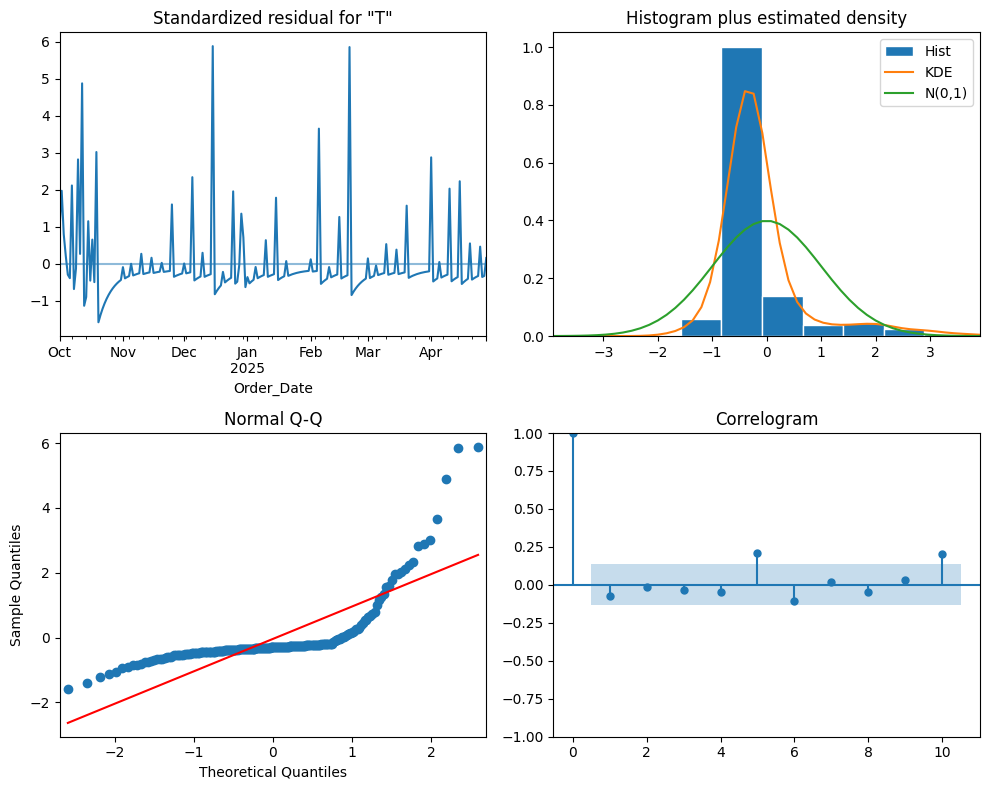

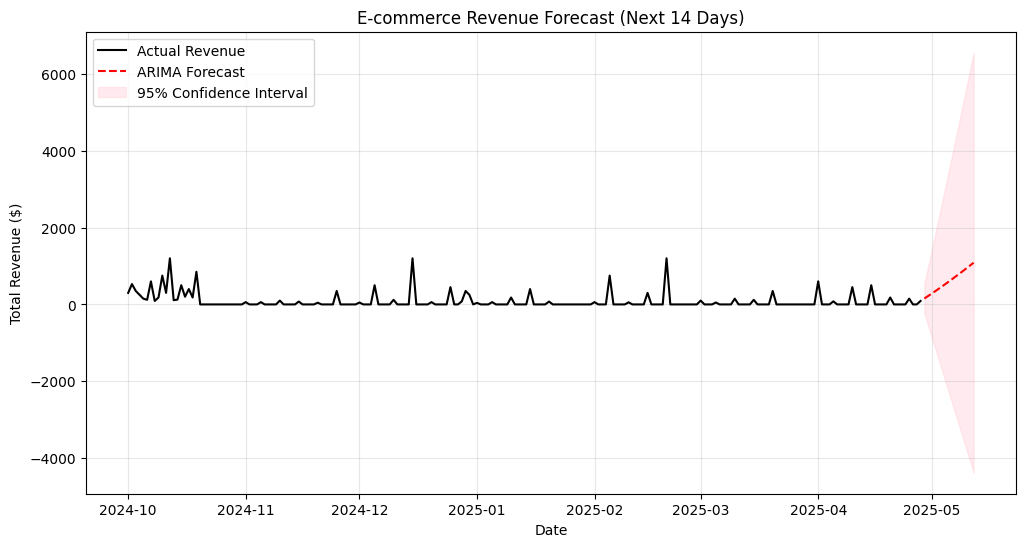


--- Final Forecasted Revenue (Actual $) ---
2025-04-29     153.802688
2025-04-30     218.919952
2025-05-01     285.296448
2025-05-02     352.879163
2025-05-03     421.617313
2025-05-04     491.462254
2025-05-05     562.367391
2025-05-06     634.288088
2025-05-07     707.181589
2025-05-08     781.006940
2025-05-09     855.724909
2025-05-10     931.297916
2025-05-11    1007.689964
2025-05-12    1084.866571
Freq: D, dtype: float64


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, yule_walker
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


file_path = 'final ecommerce.xlsx'
try:

    df = pd.read_excel(file_path)

    # Convert Order_Date to datetime and set as index
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])

    # Aggregate Total_Revenue by Date (Multiple orders in one day)
    ts = df.groupby('Order_Date')['Total_Revenue'].sum()

    # Ensure a continuous daily frequency (fills missing days with 0 revenue)
    ts = ts.asfreq('D').fillna(0)

    print(f"Success: '{file_path}' loaded and aggregated.")
    print(f"Dataset covers {ts.index.min().date()} to {ts.index.max().date()} ({len(ts)} days).")

except Exception as e:
    print(f"Error loading file: {e}")
    # Fallback to dummy data if file fails
    date_range = pd.date_range(start='2024-01-01', periods=100, freq='D')
    ts = pd.Series(np.random.randint(100, 1000, 100), index=date_range)

# 2. RAW DATA PLOT
plt.figure(figsize=(12, 5))
plt.plot(ts, color='blue', linewidth=1.5)
plt.title("Daily Total Revenue (E-commerce Data)")
plt.xlabel("Order Date")
plt.ylabel("Revenue ($)")
plt.grid(True, alpha=0.3)
plt.show()

# 3. STATIONARITY TEST (ADF)
def perform_adf_test(series):
    result = adfuller(series)
    print("\n--- ADF Test Results ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("Conclusion: Series is Stationary")
        return True
    else:
        print("Conclusion: Series is NOT Stationary")
        return False

is_stationary = perform_adf_test(ts)

# 4. DIFFERENCING (If needed)
if not is_stationary:
    print("\nApplying First-Order Differencing (d=1)...")
    ts_diff = ts.diff().dropna()
    print("Testing Stationarity again on Differenced Data:")
    perform_adf_test(ts_diff)
else:
    ts_diff = ts

# 5. YULE-WALKER ESTIMATION
print("\n--- Yule-Walker Estimation (AR Order 1) ---")
rho, sigma = yule_walker(ts_diff, order=1)
print(f"Yule-Walker AR(1) coefficient: {rho[0]:.4f}")
print(f"Estimated Error variance (Sigma): {sigma:.4f}")

# 6. MODEL SELECTION (Comparison)
ar_model = ARIMA(ts_diff, order=(1, 0, 0)).fit()
ma_model = ARIMA(ts_diff, order=(0, 0, 1)).fit()
arma_model = ARIMA(ts_diff, order=(1, 0, 1)).fit()

model_comparison = pd.DataFrame({
    "Model": ["AR(1)", "MA(1)", "ARMA(1,1)"],
    "AIC": [ar_model.aic, ma_model.aic, arma_model.aic],
    "BIC": [ar_model.bic, ma_model.bic, arma_model.bic]
})

print("\n--- Model Comparison Table ---")
print(model_comparison)

# 7. FINAL MODEL SUMMARY & DIAGNOSTICS
print("\n--- MLE Final Model Summary (ARMA 1,1) ---")
print(arma_model.summary())

# Ljung-Box Test
lb_test = acorr_ljungbox(arma_model.resid, lags=[10], return_df=True)
p_val = lb_test['lb_pvalue'].values[0]
print(f"\nLjung-Box Test p-value: {p_val:.4f}")
if p_val > 0.05:
    print("Residuals are White Noise (Model is Adequate)")
else:
    print("Residuals show Correlation (Model is Inadequate)")

arma_model.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

# 8. FORECASTING
forecast_steps = 14  # Forecasting next 2 weeks
forecast_res = arma_model.get_forecast(steps=forecast_steps)
forecast_diff_values = forecast_res.predicted_mean

# Convert differenced forecast back to actual revenue scale
last_actual_value = ts.iloc[-1]
actual_forecast_values = last_actual_value + forecast_diff_values.cumsum()

# Create index for the forecast
future_index = pd.date_range(start=ts.index[-1] + pd.Timedelta(days=1),
                             periods=forecast_steps,
                             freq='D')
actual_forecast_series = pd.Series(actual_forecast_values.values, index=future_index)

# 9. FINAL VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(ts, label="Actual Revenue", color='black')
plt.plot(actual_forecast_series, linestyle="--", label="ARIMA Forecast", color='red')

# Confidence Intervals (Integrated back to original scale)
conf_int = forecast_res.conf_int()
lower_bound = last_actual_value + conf_int.iloc[:, 0].cumsum()
upper_bound = last_actual_value + conf_int.iloc[:, 1].cumsum()

plt.fill_between(future_index, lower_bound, upper_bound, color='pink', alpha=0.3, label="95% Confidence Interval")

plt.title("E-commerce Revenue Forecast (Next 14 Days)")
plt.xlabel("Date")
plt.ylabel("Total Revenue ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Final Forecasted Revenue (Actual $) ---")
print(actual_forecast_series)